In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

In [10]:
f = pd.read_csv('passenger.csv')
df = pd.DataFrame(f)
print(df.head())

     Month  Passengers
0  1949-01         112
1  1949-02         118
2  1949-03         132
3  1949-04         129
4  1949-05         121


In [11]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Month       144 non-null    str  
 1   Passengers  144 non-null    int64
dtypes: int64(1), str(1)
memory usage: 2.4 KB
None


Data Head:
             Passengers
Month                 
1949-01-01         112
1949-02-01         118
1949-03-01         132
1949-04-01         129
1949-05-01         121


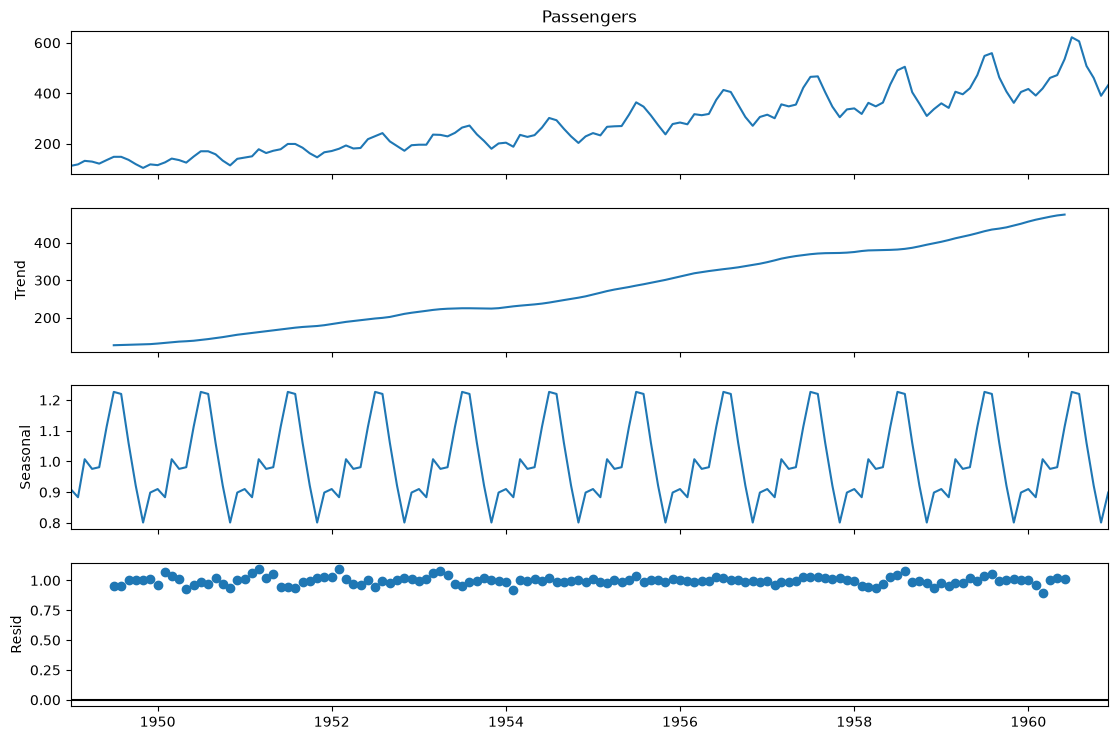

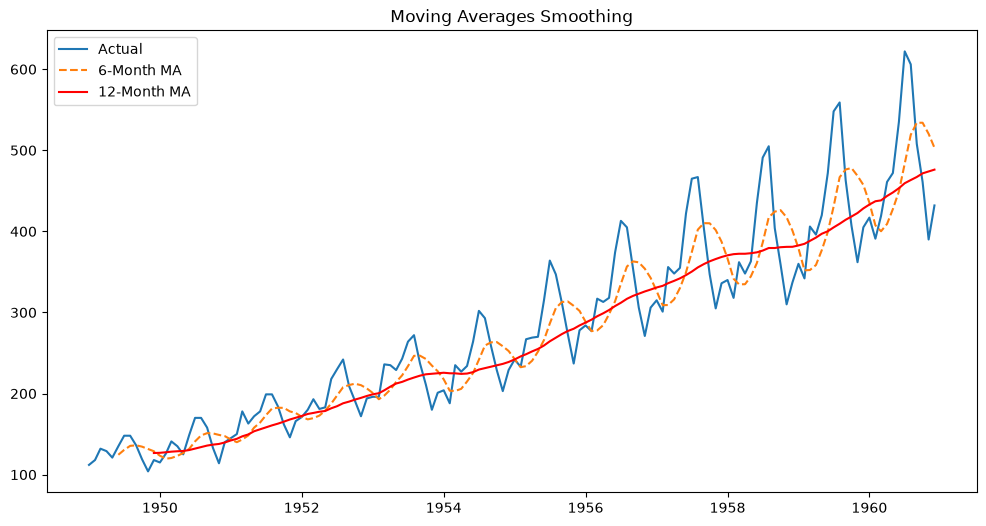

F:\SoftNexis\softenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
F:\SoftNexis\softenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
F:\SoftNexis\softenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
F:\SoftNexis\softenv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
F:\SoftNexis\softenv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using z

RMSE: 21.2 passengers


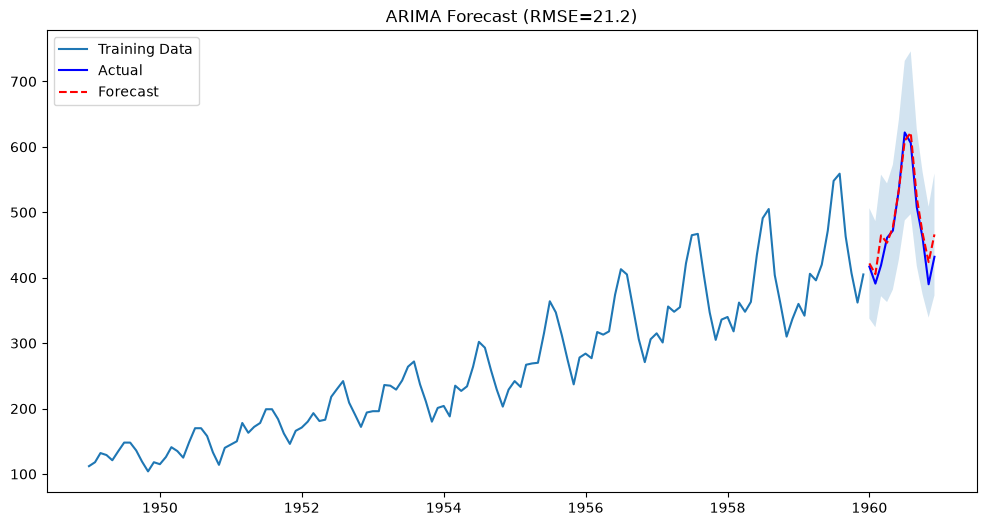

In [12]:
df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)
print("Data Head:\n", df.head())

# Updated: Resample to Quarterly mean using 'QE' instead of 'Q'
quarterly = df.resample('QE').mean()

# 2. Trend/Seasonality Decomposition
# Decompose into Trend/Seasonal/Residual using a multiplicative model
decomposition = seasonal_decompose(df['Passengers'], model='multiplicative')

# Plot components
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.show()

# 3. Moving Averages
# Calculate 6-month and 12-month moving averages
df['MA_6'] = df['Passengers'].rolling(window=6).mean()
df['MA_12'] = df['Passengers'].rolling(window=12).mean()

# Plot comparison
plt.figure(figsize=(12, 6))
plt.plot(df['Passengers'], label='Actual')
plt.plot(df['MA_6'], label='6-Month MA', linestyle='--')
plt.plot(df['MA_12'], label='12-Month MA', color='red')
plt.legend()
plt.title('Moving Averages Smoothing')
plt.show()

# 4. ARIMA Forecasting
# Split data (last 12 months for testing)
train = df['Passengers'].iloc[:-12]
test = df['Passengers'].iloc[-12:]

# Fit Seasonal ARIMA model: SARIMA (2,1,1)x(1,1,1,12)
model = ARIMA(train, order=(2, 1, 1), seasonal_order=(1, 1, 1, 12))
result = model.fit()

# Forecast and evaluate
forecast = result.forecast(steps=12)
rmse = np.sqrt(mean_squared_error(test, forecast))
print(f"RMSE: {rmse:.1f} passengers")

# Plot forecast vs actual
plt.figure(figsize=(12,6))
plt.plot(train.index, train, label='Training Data')
plt.plot(test.index, test, label='Actual', color='blue')
plt.plot(test.index, forecast, label='Forecast', color='red', linestyle='--')
plt.fill_between(test.index, forecast*0.8, forecast*1.2, alpha=0.2)
plt.title(f"ARIMA Forecast (RMSE={rmse:.1f})")
plt.legend()
plt.show()